1.**Load** the customer features.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
customer_df = pd.read_csv('/content/drive/MyDrive/GNN/bank_customer.csv')
#df = pd.read_csv('/content/drive/MyDrive/GNN/bank_customer.csv')
customer_df


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,customer_id,age,account_age_months,avg_monthly_transactions,avg_transaction_amount,international_ratio,failed_transaction_ratio,login_frequency,device_count,label
0,0,56,170,19,35.61,0.091,0.071,15,5,0
1,1,69,21,10,28.68,0.121,0.095,14,1,0
2,2,46,20,23,25.26,0.393,0.131,19,3,0
3,3,32,3,23,75.73,0.148,0.015,12,3,0
4,4,60,80,18,53.64,0.436,0.117,12,4,0
...,...,...,...,...,...,...,...,...,...,...
1495,1495,66,84,14,66.31,0.113,0.036,18,4,0
1496,1496,62,149,15,113.74,0.170,0.087,17,2,0
1497,1497,46,161,21,30.89,0.127,0.094,6,3,0
1498,1498,47,62,22,78.05,0.357,0.065,14,4,0


**2.Load the transaction relationships.**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
edge_df = pd.read_csv('/content/drive/MyDrive/GNN/bank_transaction.csv')
#df = pd.read_csv('/content/drive/MyDrive/GNN/bank_transaction.csv')
edge_df


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,source,target
0,1104,1367
1,856,1302
2,155,437
3,427,630
4,1180,1362
...,...,...
5995,350,1309
5996,424,1258
5997,427,738
5998,39,104


**3.Construct x, edge_index, and y.**

In [ ]:
import torch
import pandas as pd


# Construct x (Node Features)
feature_columns = [
    "age",
    "account_age_months",
    "avg_monthly_transactions",
    "avg_transaction_amount",
    "international_ratio",
    "failed_transaction_ratio",
    "login_frequency",
    "device_count"
]

x = torch.tensor(
    customer_df[feature_columns].values,
    dtype=torch.float
)

# Construct edge_index (Transaction Relationships)
edge_index = torch.tensor(
    edge_df[["source", "target"]].values.T,
    dtype=torch.long
)

# Construct y (Labels)
y = torch.tensor(
    customer_df["label"].values,
    dtype=torch.long
)

# Display dimensions
print("x dimension:", x.shape)
print("edge_index dimension:", edge_index.shape)
print("y dimension:", y.shape)

x dimension: torch.Size([1500, 8])
edge_index dimension: torch.Size([2, 6000])
y dimension: torch.Size([1500])


In [ ]:
!pip install torch_geometric

**4.Create a PyTorch Geometric Data object.**

In [ ]:
from torch_geometric.data import Data

# Create PyTorch Geometric Data object
data = Data(
    x=x,
    edge_index=edge_index,
    y=y
)

print(data)

Data(x=[1500, 8], edge_index=[2, 6000], y=[1500])


**5.Display the dimensions of x, edge_index, and y**

In [ ]:
print("x dimension:", x.shape)
print("edge_index dimension:", edge_index.shape)
print("y dimension:", y.shape)

x dimension: torch.Size([1500, 8])
edge_index dimension: torch.Size([2, 6000])
y dimension: torch.Size([1500])


## **TasK-2**

**1.Design a two-layer GCN.**

In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self):
        super(GCN, self).__init__()

        # First GCN layer: 3 input features -> 8 hidden features
        self.conv1 = GCNConv(3, 8)

        # Second GCN layer: 8 hidden features -> 2 output classes
        self.conv2 = GCNConv(8, 2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # First GCN layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        # Second GCN layer
        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

**2.Train the model for 100 epochs.**

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()

        # Input features = 8
        self.conv1 = GCNConv(8, 8)

        # Second GCN layer
        self.conv2 = GCNConv(8, 2)

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return x

**3.Plot the training loss.**

In [ ]:
model = GCN()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

criterion = torch.nn.CrossEntropyLoss()

loss_history = []

# Train for 100 epochs
for epoch in range(100):

    model.train()

    optimizer.zero_grad()

    # Forward pass
    out = model(data)

    # Calculate loss
    loss = criterion(out, data.y)

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    # Store loss
    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1:03d}, Loss: {loss.item():.4f}")

Epoch 010, Loss: 4.3165
Epoch 020, Loss: 1.3402
Epoch 030, Loss: 0.7433
Epoch 040, Loss: 0.6676
Epoch 050, Loss: 0.6133
Epoch 060, Loss: 0.5493
Epoch 070, Loss: 0.4916
Epoch 080, Loss: 0.4381
Epoch 090, Loss: 0.3952
Epoch 100, Loss: 0.3680


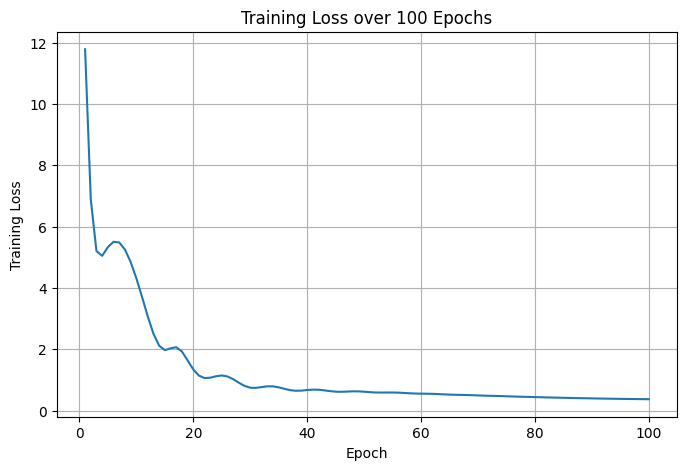

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(range(1, len(loss_history) + 1), loss_history)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss over 100 Epochs")

plt.grid(True)
plt.show()

**4.Report the final node classification accuracy.**

In [ ]:
# Evaluate the trained model
model.eval()

with torch.no_grad():
    out = model(data)

    # Get predicted class
    pred = out.argmax(dim=1)

    # Calculate accuracy
    correct = (pred == data.y).sum().item()
    total = data.y.size(0)

    accuracy = correct / total

print(f"Final Node Classification Accuracy: {accuracy * 100:.2f}%")

Final Node Classification Accuracy: 92.27%


Task:03


In [ ]:
# Task 3: Extract and Visualize Node Embeddings

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Put the trained model in evaluation mode
model.eval()

GCN(
  (conv1): GCNConv(8, 8)
  (conv2): GCNConv(8, 2)
)

In [ ]:
# 1. Extract hidden representation

with torch.no_grad():

    # Input features and graph structure
    x = data.x
    edge_index = data.edge_index

    # First GCN layer
    hidden = model.conv1(x, edge_index)

    # Apply ReLU activation
    hidden = torch.relu(hidden)

print("Hidden representation shape:", hidden.shape)

Hidden representation shape: torch.Size([1500, 8])


In [ ]:
#2. Store node embeddings

node_embeddings = hidden.cpu().numpy()

print("Node embeddings shape:", node_embeddings.shape)

# Save embeddings
np.save("node_embeddings.npy", node_embeddings)

print("Node embeddings saved successfully!")



Node embeddings shape: (1500, 8)
Node embeddings saved successfully!


In [ ]:
#3. Reduce embeddings using t-SNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

embeddings_2d = tsne.fit_transform(node_embeddings)

print("t-SNE embeddings shape:", embeddings_2d.shape)


t-SNE embeddings shape: (1500, 2)


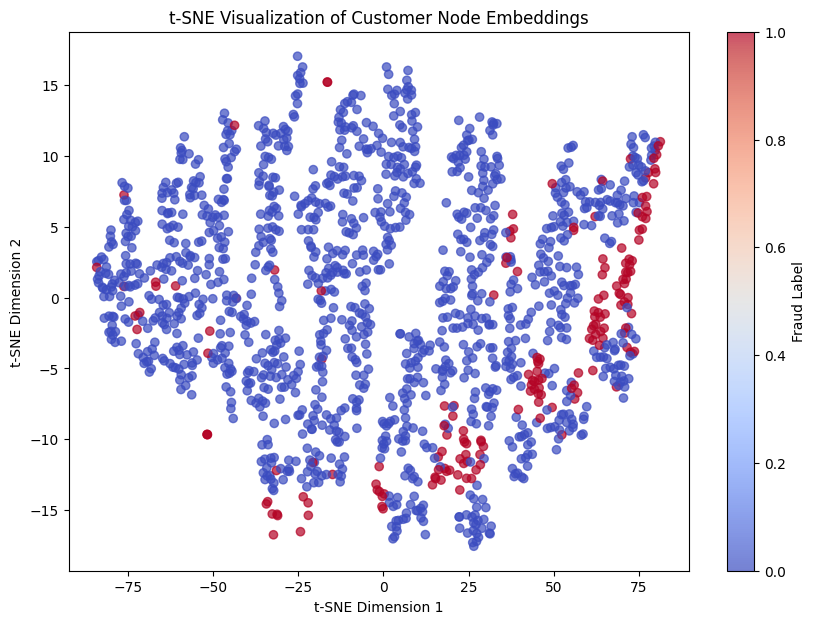

In [ ]:
# 4. Plot embeddings using fraud labels

labels = data.y.cpu().numpy()

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=labels,
    cmap="coolwarm",
    alpha=0.7
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Visualization of Customer Node Embeddings")

plt.colorbar(
    scatter,
    label="Fraud Label"
)

plt.show()

Task;04

In [ ]:
import torch

num_nodes = data.num_nodes

# Create masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

# 80% training, 20% testing
train_size = int(0.8 * num_nodes)

# Random shuffle
indices = torch.randperm(num_nodes)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

train_mask[train_indices] = True
test_mask[test_indices] = True

# Add masks to PyG Data object
data.train_mask = train_mask
data.test_mask = test_mask

print("Training nodes:", data.train_mask.sum().item())
print("Testing nodes:", data.test_mask.sum().item())

Training nodes: 1200
Testing nodes: 300


In [ ]:
losses = []

for epoch in range(100):

    sage_model.train()
    optimizer.zero_grad()

    out = sage_model(data)

    loss = F.cross_entropy(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:03d}, "
            f"Loss: {loss.item():.4f}"
        )

Epoch 010, Loss: 0.4921
Epoch 020, Loss: 0.2502
Epoch 030, Loss: 0.2384
Epoch 040, Loss: 0.1915
Epoch 050, Loss: 0.1684
Epoch 060, Loss: 0.1626
Epoch 070, Loss: 0.1403
Epoch 080, Loss: 0.1292
Epoch 090, Loss: 0.1212
Epoch 100, Loss: 0.1266


In [ ]:
sage_model.eval()

with torch.no_grad():
    out = sage_model(data)
    pred = out.argmax(dim=1)

correct = (
    pred[data.test_mask] == data.y[data.test_mask]
).sum()

accuracy = (
    correct / data.test_mask.sum()
).item()

print(f"GraphSAGE Test Accuracy: {accuracy * 100:.2f}%")

GraphSAGE Test Accuracy: 97.00%


**Confusion Matrix**


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = data.y[data.test_mask].cpu().numpy()
y_pred = pred[data.test_mask].cpu().numpy()

cm_sage = confusion_matrix(y_true, y_pred)

print("GraphSAGE Confusion Matrix:")
print(cm_sage)

Plot


In [1]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_sage,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Fraud", "Fraud"],
    yticklabels=["Non-Fraud", "Fraud"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("GraphSAGE Confusion Matrix")

plt.show()

NameError: name 'plt' is not defined